In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("social_media_addiction_200_rows.xlsx")
df.head()

,Student_ID,Age,Gender,Year_of_Study,Major,Daily_Usage_Hours,Primary_Platform,Study_Hours_Per_Day,Sleep_Hours,Screen_Time_Night,Notifications_Per_Day,GPA,Stress_Level,Physical_Activity_Hours,Social_Interaction_Score,Addiction_Level
0,1,24,Female,4th,Science,3.7,Snapchat,4.9,7.9,0.1,41,9.27,8,0.5,3,Medium
1,2,21,Male,1st,Arts,1.0,TikTok,1.1,5.8,3.6,173,8.14,1,4.5,10,Low
2,3,22,Male,4th,Arts,1.1,YouTube,5.2,8.3,3.4,146,9.62,8,1.9,5,Low
3,4,24,Female,1st,Engineering,4.4,YouTube,4.6,5.1,1.8,22,7.64,9,4.1,5,High
4,5,20,Female,2nd,Business,4.1,Snapchat,2.7,8.9,1.6,146,7.42,4,4.8,6,High


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Primary_Platform'] = le.fit_transform(df['Primary_Platform'])
df['Year_of_Study'] = le.fit_transform(df['Year_of_Study'])

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                200 non-null    int64  
 1   Age                       200 non-null    int64  
 2   Gender                    200 non-null    int64  
 3   Year_of_Study             200 non-null    int64  
 4   Major                     200 non-null    object 
 5   Daily_Usage_Hours         200 non-null    float64
 6   Primary_Platform          200 non-null    int64  
 7   Study_Hours_Per_Day       200 non-null    float64
 8   Sleep_Hours               200 non-null    float64
 9   Screen_Time_Night         200 non-null    float64
 10  Notifications_Per_Day     200 non-null    int64  
 11  GPA                       200 non-null    float64
 12  Stress_Level              200 non-null    int64  
 13  Physical_Activity_Hours   200 non-null    float64
 14  Social_Int

In [14]:
X = df.drop(['Student_ID','Addiction_Level'], axis=1)

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [17]:
from sklearn.preprocessing import StandardScaler

X = df.drop(['Student_ID'], axis=1)  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

C:\Users\jashwitha\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\jashwitha\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\jashwitha\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\jashwitha\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~

   Student_ID  Age  Gender  Year_of_Study  Major  Daily_Usage_Hours  \
0           1   24       0              3      3                3.7   
1           2   21       1              0      0                1.0   
2           3   22       1              3      0                1.1   
3           4   24       0              0      2                4.4   
4           5   20       0              1      1                4.1   

   Primary_Platform  Study_Hours_Per_Day  Sleep_Hours  Screen_Time_Night  \
0                 1                  4.9          7.9                0.1   
1                 2                  1.1          5.8                3.6   
2                 3                  5.2          8.3                3.4   
3                 3                  4.6          5.1                1.8   
4                 1                  2.7          8.9                1.6   

   Notifications_Per_Day   GPA  Stress_Level  Physical_Activity_Hours  \
0                     41  9.27             

C:\Users\jashwitha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [19]:
y_true = df['Addiction_Level']
y_pred = df['Cluster']

In [20]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Confusion Matrix:
[[88  0  4]
 [ 0 24 19]
 [ 0 37 28]]
Accuracy: 0.7


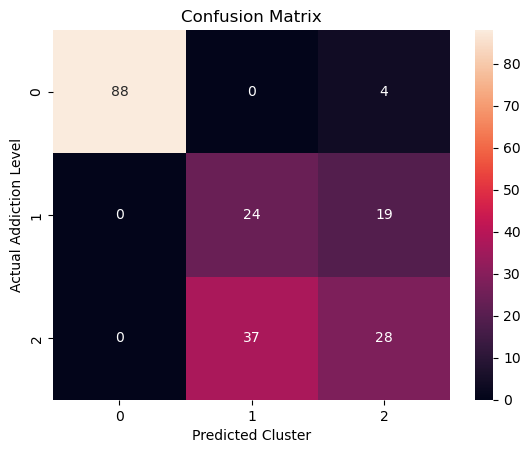

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Addiction Level")
plt.title("Confusion Matrix")
plt.show()

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
x = df.drop('Addiction_Level', axis=1)   # features
y = df['Addiction_Level']                # target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = rf.predict(x_test)

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[16  0  0]
 [ 0 11  0]
 [ 0  0 13]]
Accuracy: 1.0


In [29]:
print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Year_of_Study', 'Major',
       'Daily_Usage_Hours', 'Primary_Platform', 'Study_Hours_Per_Day',
       'Sleep_Hours', 'Screen_Time_Night', 'Notifications_Per_Day', 'GPA',
       'Stress_Level', 'Physical_Activity_Hours', 'Social_Interaction_Score',
       'Addiction_Level', 'Cluster'],
      dtype='object')


Index(['Student_ID', 'Age', 'Daily_Usage_Hours', 'Study_Hours_Per_Day',
       'Sleep_Hours', 'Screen_Time_Night', 'Notifications_Per_Day', 'GPA',
       'Stress_Level', 'Physical_Activity_Hours', 'Social_Interaction_Score',
       'Gender_Male', 'Year_of_Study_2nd', 'Year_of_Study_3rd',
       'Year_of_Study_4th', 'Major_Business', 'Major_Engineering',
       'Major_Science', 'Primary_Platform_Snapchat', 'Primary_Platform_TikTok',
       'Primary_Platform_YouTube', 'Addiction_Level_Low',
       'Addiction_Level_Medium'],
      dtype='object')


In [41]:
df['Addiction_Level'] = df[['Addiction_Level_Low',
                            'Addiction_Level_Medium']].idxmax(axis=1)

df['Addiction_Level'] = df['Addiction_Level'].str.replace('Addiction_Level_', '')

In [46]:
dummy_cols = [col for col in df.columns if col.startswith(('Gender_','Primary_Platform_'))]

df = df.drop(dummy_cols, axis=1)

In [43]:
addiction_cols = [col for col in df.columns if 'Addiction_Level_' in col]

df = df.drop(addiction_cols, axis=1)

In [50]:
print(df.columns)

Index(['Student_ID', 'Age', 'Daily_Usage_Hours', 'Study_Hours_Per_Day',
       'Sleep_Hours', 'Screen_Time_Night', 'Notifications_Per_Day', 'GPA',
       'Stress_Level', 'Physical_Activity_Hours', 'Social_Interaction_Score',
       'Year_of_Study_2nd', 'Year_of_Study_3rd', 'Year_of_Study_4th',
       'Major_Business', 'Major_Engineering', 'Major_Science',
       'Addiction_Level'],
      dtype='object')


In [51]:
dummy_cols = [col for col in df.columns if col.startswith(('Gender_','Primary_Platform_','Major_','Year_of_Study_','Screen_Time_'))]

df = df.drop(dummy_cols, axis=1)

In [52]:
print(df.columns)

Index(['Student_ID', 'Age', 'Daily_Usage_Hours', 'Study_Hours_Per_Day',
       'Sleep_Hours', 'Notifications_Per_Day', 'GPA', 'Stress_Level',
       'Physical_Activity_Hours', 'Social_Interaction_Score',
       'Addiction_Level'],
      dtype='object')


In [53]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [56]:
y_pred = dt.predict(X_test)

In [57]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[16  0  0]
 [ 0 11  0]
 [ 0  0 13]]


In [58]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


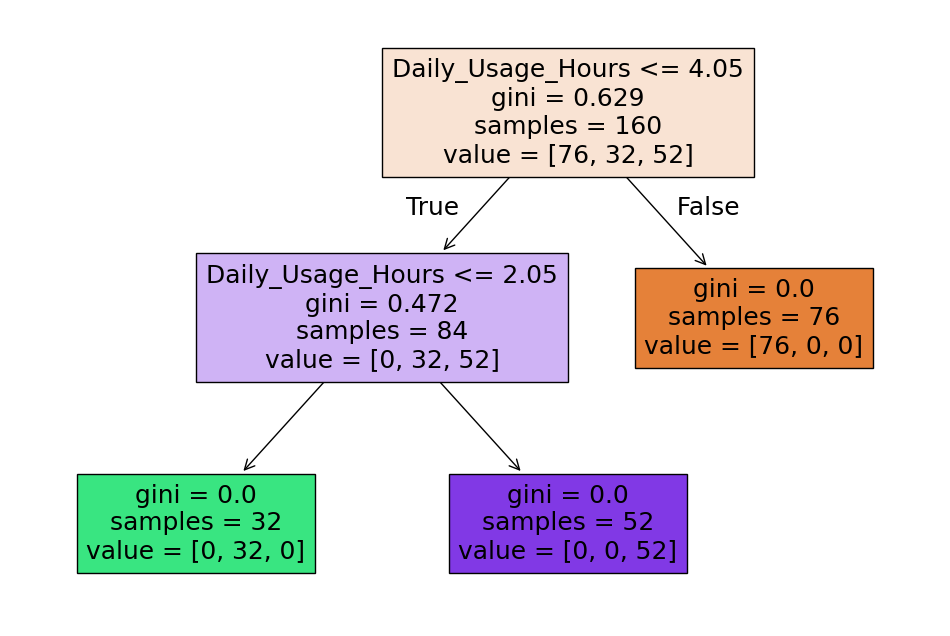

In [59]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.show()

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [61]:
df = pd.read_excel("social_media_addiction_200_rows.xlsx")

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [63]:
X = df.drop('GPA', axis=1)
y = df['GPA']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
model = LinearRegression()

model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
y_pred = model.predict(X_test)

In [67]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.2558677267957049


In [68]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6017417988988658


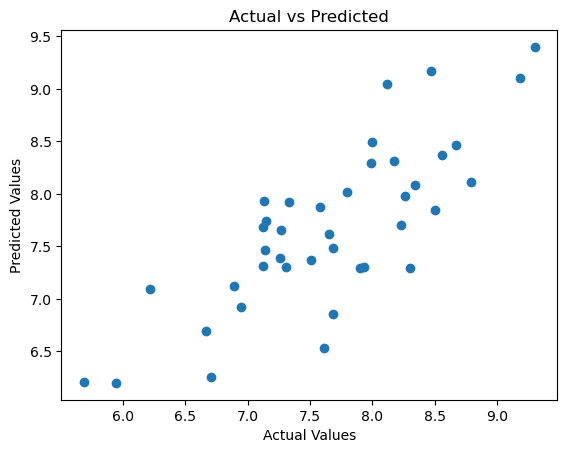

In [69]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()